## Range Retention Analysis
### Cohort Analysis

## 📊 분석 개요

본 분석은 EDA를 통해 파악한 데이터를 기반으로 **고객 코호트 분석(Cohort Analysis)** 을 수행한다.

고객의 첫 구매 시점(월)을 기준으로 코호트를 구성하고, 시간 경과에 따른 **Range Retention(구간별 재구매율)** 을 분석하여 고객의 재구매 패턴을 파악한다.

### 데이터 준비

전체 데이터를 기준으로 고객별 **첫 구매 일자**와 **구매 간격(month_diff)** 을 계산한다.

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

load_dotenv()  # .env 파일 로드

# MySQL 연결
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)


query = """
    WITH first_purchases AS (
        SELECT 
            CustomerID,
            MIN(OrderDate) AS first_purchase_date,
            DATE_FORMAT(MIN(OrderDate), '%Y-%m') AS first_purchase_month
        FROM orders_info
        GROUP BY CustomerID
    )
    SELECT 
        o.OrderDate,
        o.CustomerID,
        f.first_purchase_date,
        f.first_purchase_month,
        TIMESTAMPDIFF(MONTH, f.first_purchase_date, o.OrderDate) AS month_diff
    FROM orders_info o
    LEFT JOIN first_purchases f ON o.CustomerID = f.CustomerID
    ORDER BY o.OrderDate
"""

df_with_first_purchase = pd.read_sql(query, engine)

In [2]:
df_with_first_purchase.head()

,OrderDate,CustomerID,first_purchase_date,first_purchase_month,month_diff
0,2020-01-01,CUST041034,2020-01-01,2020-01,0
1,2020-01-01,CUST009794,2020-01-01,2020-01,0
2,2020-01-01,CUST049244,2020-01-01,2020-01,0
3,2020-01-01,CUST016167,2020-01-01,2020-01,0
4,2020-01-01,CUST042663,2020-01-01,2020-01,0


In [3]:
# 월별 첫 구매 고객 수 집계
first_purchase_count = (
    df_with_first_purchase
    .groupby('first_purchase_month')['CustomerID']
    .nunique()
    .reset_index()
    .rename(columns={'CustomerID': 'counts'})
)
first_purchase_count.head()

,first_purchase_month,counts
0,2020-01,1697
1,2020-02,1417
2,2020-03,1560
3,2020-04,1531
4,2020-05,1459


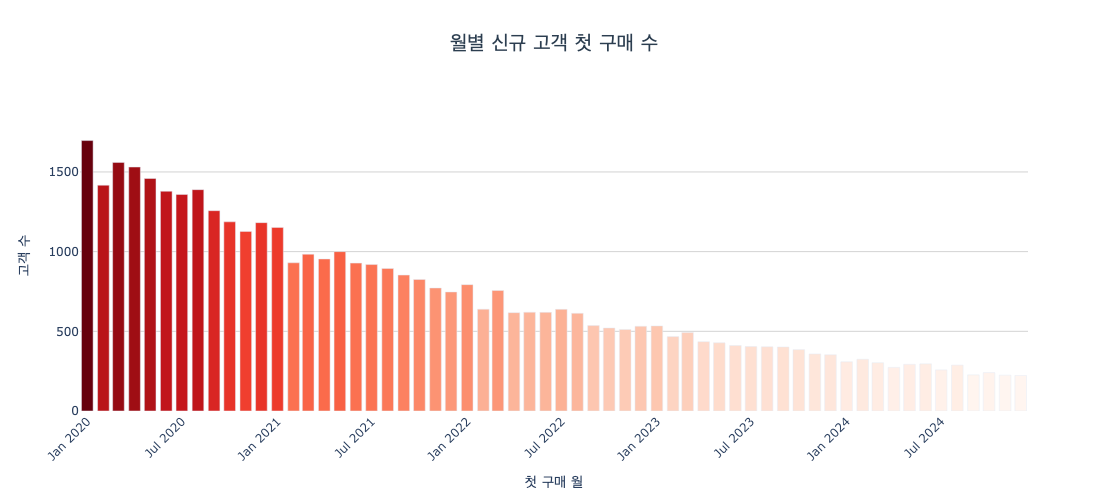

In [4]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=first_purchase_count['first_purchase_month'],
    y=first_purchase_count['counts'],
    marker=dict(color=first_purchase_count['counts'], colorscale='Reds', showscale=False)
))

y_max = first_purchase_count['counts'].max()

fig.update_layout(
    title=dict(text='월별 신규 고객 첫 구매 수', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='첫 구매 월',
    yaxis_title='고객 수',
    xaxis_tickangle=-45,
    plot_bgcolor='white',
    yaxis=dict(showgrid=True, gridcolor='lightgray', range=[0, y_max * 1.15]),
    height=500
)

fig.show()

## Retention Analysis

### 문제 상황

월별 첫 구매 고객 수를 확인한 결과, 시간이 지날수록 **신규 고객 유입이 점차 감소하는 경향**이 나타났다.  
이러한 상황에서는 신규 고객 확보(acquisition)보다 **기존 고객의 재구매율(retention)을 높이는 전략**이 더욱 중요하다.

따라서 본 분석에서는 **재구매율이 높은 고객군의 특징을 파악하고, 재구매율을 높일 수 있는 요인을 탐색**하고자 한다.

---

### 리텐션 분석 범위 설정

데이터의 주문 날짜를 확인한 결과 **2020/01/01부터 2024/12/29까지 약 5년간의 주문 데이터가 존재**한다.

리텐션 분석은 다음 두 단계로 진행한다.

1. **연도별 코호트 비교 (2020~2023)** : 역대 리텐션 수준을 파악하여 기준선을 설정한다.
2. **2024년 월별 코호트 분석** : 기준선 대비 특정 달에 리텐션이 두드러지게 높은 코호트를 탐색한다.

고객의 첫 구매일은 **전체 기간 데이터를 기준으로 계산**하여,  
기존 고객을 신규 고객으로 잘못 분류하는 문제를 방지하였다.

### 연도별 코호트 평균 재구매 주기

각 연도에 첫 구매한 고객 코호트(2020~2024)를 기준으로, **첫 구매 후 12개월 이내** 재구매 간격을 계산한다.  
관측 기간을 12개월로 동일하게 제한하여 연도 간 비교가 가능하도록 한다.

`LAG()` 윈도우 함수로 이전 주문일을 구하고, 두 주문 사이의 **구매 간격(일 단위)** 을 계산하였다.  
첫 주문은 이전 주문이 없으므로 제외하고, 고객별 **평균 재구매 주기(avg_cycle)** 를 산출하였다.

In [5]:
# 연도별 코호트 구매 사이클 확인 (첫 구매 후 12개월 이내)
order_cycle_yearly = pd.read_sql(
    """
    WITH First_Purchase AS (
        SELECT
            CustomerID,
            MIN(OrderDate) AS first_purchase,
            YEAR(MIN(OrderDate)) AS cohort_year
        FROM orders_info
        GROUP BY CustomerID
    ),
    OrderWithCycle AS (
        SELECT
            o.CustomerID,
            fp.cohort_year,
            o.OrderDate,
            LAG(o.OrderDate) OVER (PARTITION BY o.CustomerID ORDER BY o.OrderDate) AS PrevOrderDate
        FROM orders_info o
        JOIN First_Purchase fp ON o.CustomerID = fp.CustomerID
        WHERE o.OrderDate <= DATE_ADD(fp.first_purchase, INTERVAL 12 MONTH)
    ),
    Purchase_Cycle AS (
        SELECT
            CustomerID,
            cohort_year,
            TIMESTAMPDIFF(DAY, PrevOrderDate, OrderDate) AS DaysBetweenOrders
        FROM OrderWithCycle
        WHERE PrevOrderDate IS NOT NULL
    )
    SELECT
        CustomerID,
        cohort_year,
        COUNT(*) AS repurchase_cnt,
        ROUND(AVG(DaysBetweenOrders), 1) AS avg_cycle
    FROM Purchase_Cycle
    GROUP BY CustomerID, cohort_year;
    """,
    engine
)
order_cycle_yearly.head()

,CustomerID,cohort_year,repurchase_cnt,avg_cycle
0,CUST000002,2020,1,272.0
1,CUST000004,2023,1,41.0
2,CUST000006,2020,1,326.0
3,CUST000010,2024,1,273.0
4,CUST000017,2024,1,218.0


In [6]:
order_cycle_yearly.groupby('cohort_year')['avg_cycle'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
cohort_year,,,,,,,,
2020,5517.0,170.4,101.7,0.0,87.5,158.5,255.0,366.0
2021,3564.0,170.7,101.2,0.0,89.0,157.5,255.0,365.0
2022,2458.0,168.4,100.4,0.0,88.0,155.0,248.0,365.0
2023,1694.0,173.7,100.2,0.0,96.0,161.0,255.8,366.0
2024,613.0,118.4,83.4,0.0,49.0,107.0,183.0,344.0


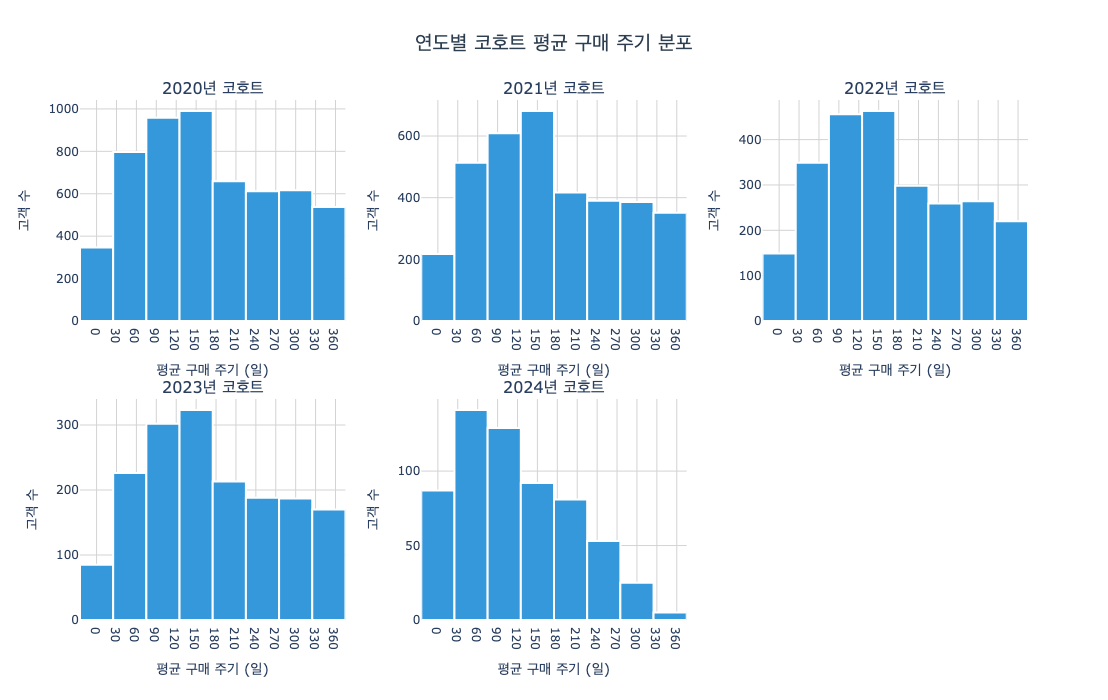

In [7]:
years = sorted(order_cycle_yearly['cohort_year'].unique())
n_cols = 3
n_rows = -(-len(years) // n_cols)  # ceiling division

fig = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=[f'{y}년 코호트' for y in years],
    shared_xaxes=False,
    vertical_spacing=0.15,
    horizontal_spacing=0.08
)

for idx, year in enumerate(years):
    row = idx // n_cols + 1
    col = idx % n_cols + 1
    data = order_cycle_yearly[order_cycle_yearly['cohort_year'] == year]
    fig.add_trace(
        go.Histogram(
            x=data['avg_cycle'],
            nbinsx=12,
            marker=dict(
                color='#3498db',
                line=dict(color='white', width=2)
            ),
            hovertemplate='구매 주기: %{x}일<br>고객 수: %{y}<extra></extra>',
            name=str(year)
        ),
        row=row, col=col
    )

# 축 스타일 일괄 적용
for key in fig['layout']:
    if key.startswith('xaxis'):
        fig['layout'][key].update(
            showgrid=True, gridcolor='lightgray',
            dtick=30, title_text='평균 구매 주기 (일)'
        )
    if key.startswith('yaxis'):
        fig['layout'][key].update(
            showgrid=True, gridcolor='lightgray',
            title_text='고객 수'
        )

fig.update_layout(
    title=dict(
        text='연도별 코호트 평균 구매 주기 분포',
        x=0.5, xanchor='center',
        font=dict(size=20, color='#2c3e50')
    ),
    plot_bgcolor='white',
    height=700,
    showlegend=False
)

fig.show()

### **구매 주기 선정 : 3개월**

연도별 코호트 구매 주기 히스토그램을 확인한 결과, 모든 연도에서 분포가 오른쪽으로 치우친 형태가 공통적으로 나타났다.  
특이값의 영향을 줄이기 위해 **중앙값(Median)** 을 기준으로 구매 주기를 선정하였다.

| 코호트 연도 | 중앙값 (일) | 월 환산 |
|:-----------:|:-----------:|:-------:|
| 2020 | ~ 150일 | 약 5개월 |
| 2021 | ~ 150일 | 약 5개월 |
| 2022 | ~ 120일 | 약 4개월 |
| 2023 | ~ 120일 | 약 4개월 |
| 2024 | ~ 107일 | 약 3개월 |

전반적으로 **3~5개월 수준**에 분포하며, 최근 코호트(2023~2024)일수록 구매 주기가 짧아지는 경향이 확인된다.  
연도 간 비교 일관성과 해석의 용이성을 위해 **구매 주기를 3개월 단위로 통일**하여 분석을 진행한다.

### 연도별 리텐션 현황 (2020~2023)

2024년 코호트를 분석하기 전, **역대 연도별 리텐션 수준을 먼저 파악**하여 기준선을 설정한다.

2020 ~ 2023년에 첫 구매한 고객을 각 연도 코호트로 정의하고,  
첫 구매 이후 12개월 이내의 재구매 패턴을 동일한 Range 구간(0~4)으로 분석한다.

In [8]:
# 2020~2023 연도별 코호트 데이터 로드
yearly_cohort = pd.read_sql(
    """
    WITH First_Purchase AS (
        SELECT
            CustomerID,
            MIN(OrderDate) AS first_purchase_date,
            YEAR(MIN(OrderDate)) AS cohort_year
        FROM orders_info
        GROUP BY CustomerID
    )
    SELECT
        o.CustomerID,
        o.OrderDate,
        fp.first_purchase_date,
        fp.cohort_year,
        TIMESTAMPDIFF(MONTH, fp.first_purchase_date, o.OrderDate) AS month_diff
    FROM orders_info o
    JOIN First_Purchase fp ON o.CustomerID = fp.CustomerID
    WHERE fp.cohort_year BETWEEN 2020 AND 2023
      AND o.OrderDate <= DATE_ADD(fp.first_purchase_date, INTERVAL 12 MONTH)
    """,
    engine
)
yearly_cohort.head()

,CustomerID,OrderDate,first_purchase_date,cohort_year,month_diff
0,CUST001504,2023-01-31,2023-01-31,2023,0
1,CUST000178,2023-12-30,2023-10-11,2023,2
2,CUST047516,2022-05-10,2021-10-14,2021,6
3,CUST048677,2023-02-04,2023-02-04,2023,0
4,CUST042705,2021-01-23,2021-01-23,2021,0


In [9]:
def calculate_retention_yearly(df):
    ranges = {
        'Range0': (0, 0),
        'Range1': (1, 3),
        'Range2': (4, 6),
        'Range3': (7, 9),
        'Range4': (10, 12)
    }
    result = []
    for year in sorted(df['cohort_year'].unique()):
        cohort = df[df['cohort_year'] == year]
        base_count = cohort['CustomerID'].nunique()
        for range_name, (low, high) in ranges.items():
            if range_name == 'Range0':
                rate = 100.0
            else:
                count = cohort[
                    (cohort['month_diff'] >= low) &
                    (cohort['month_diff'] <= high)
                ]['CustomerID'].nunique()
                rate = round(count / base_count * 100, 2)
            result.append({
                'cohort_year': str(year),
                'range': range_name,
                'retention_rate': rate
            })
    return pd.DataFrame(result)

yearly_retention_df = calculate_retention_yearly(yearly_cohort)
yearly_retention_pivot = yearly_retention_df.pivot(
    index='cohort_year', columns='range', values='retention_rate'
)
yearly_retention_pivot

range,Range0,Range1,Range2,Range3,Range4
cohort_year,,,,,
2020,100.0,9.54,9.50,9.37,6.74
2021,100.0,9.09,9.61,8.94,6.68
2022,100.0,9.65,9.84,8.94,6.64
2023,100.0,9.36,10.15,9.64,6.84


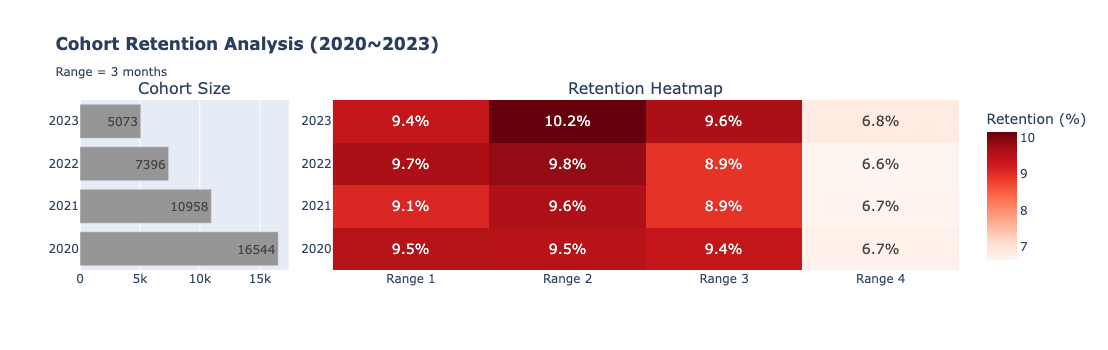

In [10]:
# 코호트별 신규 고객 수 (Cohort Size)
cohort_size = (
    yearly_cohort.groupby('cohort_year')['CustomerID']
    .nunique()
    .reset_index()
    .rename(columns={'CustomerID': 'cohort_size'})
)
cohort_size['cohort_year'] = cohort_size['cohort_year'].astype(str)

# 리텐션 데이터 준비
pivot = yearly_retention_pivot[['Range1', 'Range2', 'Range3', 'Range4']].copy()
pivot.columns = ['Range 1', 'Range 2', 'Range 3', 'Range 4']
pivot = pivot.sort_index(ascending=False)

# Cohort Size도 동일 순서로 정렬
cohort_size = cohort_size.set_index('cohort_year').reindex(pivot.index).reset_index()

# 0% 값은 텍스트 숨김
custom_text = []
for row in pivot.values:
    row_text = []
    for val in row:
        if val == 0 or np.isnan(val):
            row_text.append('')
        else:
            row_text.append(f'{val:.1f}%')
    custom_text.append(row_text)

fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.25, 0.75],
    subplot_titles=('Cohort Size', 'Retention Heatmap'),
    horizontal_spacing=0.05
)

fig.add_trace(
    go.Bar(
        x=cohort_size['cohort_size'],
        y=pivot.index,
        orientation='h',
        text=cohort_size['cohort_size'],
        textposition='auto',
        marker_color='rgb(150,150,150)',
        showlegend=False
    ),
    row=1, col=1
)

fig.add_trace(
    go.Heatmap(
        z=pivot.values,
        x=pivot.columns,
        y=pivot.index,
        colorscale='Reds',
        text=custom_text,
        texttemplate='%{text}',
        textfont={'size': 14},
        colorbar=dict(title='Retention (%)')
    ),
    row=1, col=2
)

fig.update_yaxes(autorange='reversed')

fig.update_layout(
    title=dict(text='Cohort Retention Analysis (2020~2023)<br><sub>Range = 3 months</sub>', font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'),
    height=350,
    width=1200
)

fig.show()

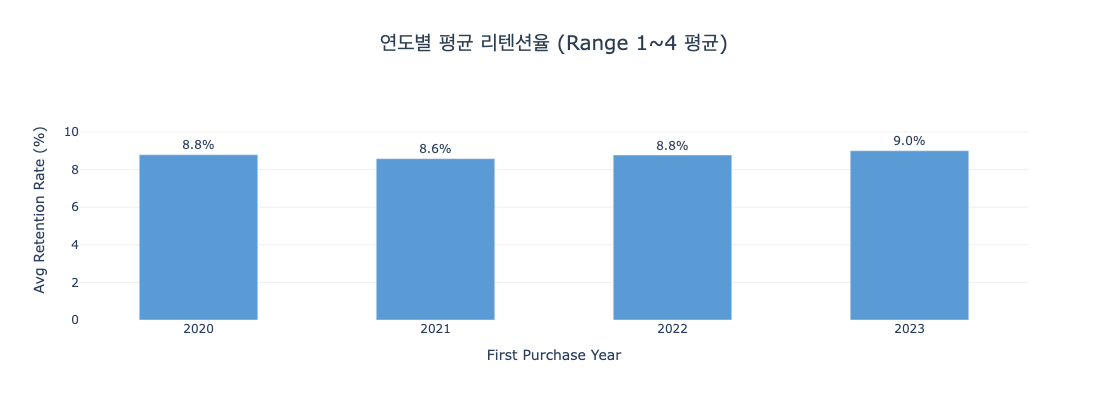

In [11]:
avg_retention = (
    yearly_retention_df[yearly_retention_df['range'] != 'Range0']
    .groupby('cohort_year')['retention_rate']
    .mean()
    .reset_index()
    .rename(columns={'retention_rate': 'avg_retention'})
)
avg_retention['avg_retention'] = avg_retention['avg_retention'].round(2)

fig = go.Figure(go.Bar(
    x=avg_retention['cohort_year'],
    y=avg_retention['avg_retention'],
    text=[f'{v:.1f}%' for v in avg_retention['avg_retention']],
    textposition='outside',
    marker_color='#5B9BD5',
    width=0.5
))

fig.update_layout(
    title=dict(
        text='연도별 평균 리텐션율 (Range 1~4 평균)',
        x=0.5,
        xanchor='center',
        font=dict(size=20, color='#2c3e50')
    ),
    xaxis_title='First Purchase Year',
    yaxis_title='Avg Retention Rate (%)',
    plot_bgcolor='white',
    yaxis=dict(
        gridcolor='#f0f0f0',
        range=[0, avg_retention['avg_retention'].max() * 1.3]
    ),
    height=400
)

fig.show()

### 연도별 리텐션 기준선 확인

연도별 코호트 분석 결과, 2020~2023년 전반에 걸쳐 재구매율은 **일관되게 한 자릿수 중반대** 수준임을 확인하였다.  
연도별 편차가 크지 않고 전반적으로 유사한 패턴을 보이는 것으로 보아, **구조적인 리텐션 한계**가 존재함을 시사한다.

이를 기준선으로 삼아 **2024년 신규 고객을 월별로 세분화**한다.  
월별 코호트 중 기준선을 유의미하게 상회하는 달이 존재한다면,  
해당 코호트의 특성을 분석하여 **리텐션을 높이는 요인을 파악**할 수 있다.

In [12]:
df_with_first_purchase['first_purchase_month'] = pd.to_datetime(df_with_first_purchase['first_purchase_month'])

In [13]:
# 2024년 첫 구매자 데이터 프레임 생성
df_with_first_purchase_2024 = df_with_first_purchase[df_with_first_purchase['first_purchase_month'].dt.year == 2024]

In [14]:
df_with_first_purchase_2024.head()

,OrderDate,CustomerID,first_purchase_date,first_purchase_month,month_diff
80131,2024-01-01,CUST019415,2024-01-01,2024-01-01,0
80135,2024-01-01,CUST018380,2024-01-01,2024-01-01,0
80138,2024-01-01,CUST023865,2024-01-01,2024-01-01,0
80139,2024-01-01,CUST033266,2024-01-01,2024-01-01,0
80142,2024-01-01,CUST035137,2024-01-01,2024-01-01,0


In [15]:
# 2024년 월별 첫 구매 고객 수 집계
first_purchase_monthly_counts = (
    df_with_first_purchase_2024
    .groupby('first_purchase_month')['CustomerID']
    .nunique()
    .rename('counts')
    .reset_index()
)
first_purchase_monthly_counts.head()

,first_purchase_month,counts
0,2024-01-01,309
1,2024-02-01,325
2,2024-03-01,303
3,2024-04-01,274
4,2024-05-01,293


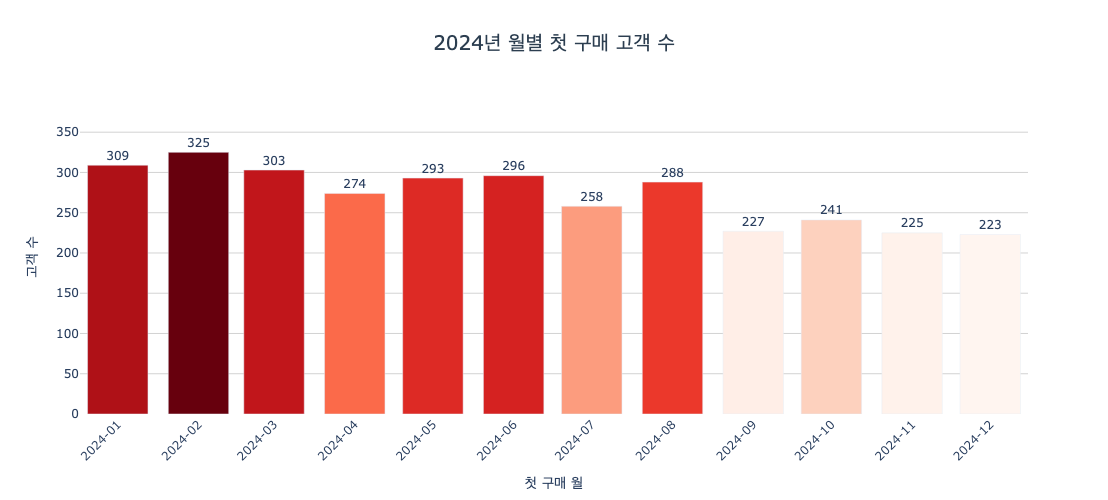

In [16]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=first_purchase_monthly_counts['first_purchase_month'],
    y=first_purchase_monthly_counts['counts'],
    text=first_purchase_monthly_counts['counts'],
    textposition='outside',
    marker=dict(color=first_purchase_monthly_counts['counts'], colorscale='Reds', showscale=False)
))

y_max = first_purchase_monthly_counts['counts'].max()

fig.update_layout(
    title=dict(text='2024년 월별 첫 구매 고객 수', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='첫 구매 월',
    yaxis_title='고객 수',
    xaxis=dict(
        tickmode='array',
        tickvals=first_purchase_monthly_counts['first_purchase_month'],
        ticktext=[d.strftime('%Y-%m') for d in first_purchase_monthly_counts['first_purchase_month']],
        tickangle=-45
    ),
    plot_bgcolor='white',
    yaxis=dict(showgrid=True, gridcolor='lightgray', range=[0, y_max * 1.2]),
    height=500
)

fig.show()

### 시각화 결과

2024년 월별 첫 구매 고객 수를 확인한 결과, **1~3월 코호트의 규모가 가장 크고** 이후 점차 감소하는 추세다.  
코호트 크기가 클수록 리텐션 계산의 통계적 신뢰도가 높아지므로, 초반 코호트의 분석 결과가 상대적으로 신뢰할 만하다.

이제 각 월별 코호트가 첫 구매 이후 얼마나 재구매로 이어지는지 **리텐션 분석**을 진행한다.

In [17]:
# 데이터 확인
df_with_first_purchase_2024 = df_with_first_purchase_2024.copy()
df_with_first_purchase_2024['OrderDate'] = pd.to_datetime(df_with_first_purchase_2024['OrderDate'])
df_with_first_purchase_2024['first_purchase_month'] = pd.to_datetime(df_with_first_purchase_2024['first_purchase_date']).dt.to_period('M')

print(f"\n전체 데이터: {len(df_with_first_purchase_2024):,}건")
print(f"기간: {df_with_first_purchase_2024['OrderDate'].min().date()} ~ {df_with_first_purchase_2024['OrderDate'].max().date()}")
print(f"고유 고객: {df_with_first_purchase_2024['CustomerID'].nunique():,}명")

print("\n데이터 샘플:")
df_with_first_purchase_2024.head()


전체 데이터: 3,944건
기간: 2024-01-01 ~ 2024-12-29
고유 고객: 3,262명

데이터 샘플:


,OrderDate,CustomerID,first_purchase_date,first_purchase_month,month_diff
80131,2024-01-01,CUST019415,2024-01-01,2024-01,0
80135,2024-01-01,CUST018380,2024-01-01,2024-01,0
80138,2024-01-01,CUST023865,2024-01-01,2024-01,0
80139,2024-01-01,CUST033266,2024-01-01,2024-01,0
80142,2024-01-01,CUST035137,2024-01-01,2024-01,0


In [18]:
def get_range(m):
    if 1 <= m <= 3:
        return 'Range1'
    elif 4 <= m <= 6:
        return 'Range2'
    elif 7 <= m <= 9:
        return 'Range3'
    elif 10 <= m <= 12:
        return 'Range4'
    else:
        return None

df_with_first_purchase_2024['range'] = df_with_first_purchase_2024['month_diff'].apply(get_range)
df_with_first_purchase_2024.head()

,OrderDate,CustomerID,first_purchase_date,first_purchase_month,month_diff,range
80131,2024-01-01,CUST019415,2024-01-01,2024-01,0,None
80135,2024-01-01,CUST018380,2024-01-01,2024-01,0,None
80138,2024-01-01,CUST023865,2024-01-01,2024-01,0,None
80139,2024-01-01,CUST033266,2024-01-01,2024-01,0,None
80142,2024-01-01,CUST035137,2024-01-01,2024-01,0,None


In [19]:
def calculate_retention_monthly(df):
    """
    월별 코호트 리텐션 계산
    
    Range 0: 첫 구매 고객 수 (첫 구매월)
    Range 1: 첫 구매 이후 1~3개월 재구매 비율 (Range 0 기준)
    Range 2: 첫 구매 이후 4~6개월 재구매 비율 (Range 0 기준)
    Range 3: 첫 구매 이후 7~9개월 재구매 비율 (Range 0 기준)
    Range 4: 첫 구매 이후 10~12개월 재구매 비율 (Range 0 기준)
    
    ※ 모든 비율은 Range 0 기준
    """
    
    results = []
    
    # 첫 구매월별로 그룹화
    cohorts = sorted(df['first_purchase_month'].unique())
    
    for cohort_month in cohorts:
        # 해당 월에 첫 구매한 고객들
        cohort_customers = df[df['first_purchase_month'] == cohort_month]['CustomerID'].unique()
        range0 = len(cohort_customers)  # 첫 구매 고객 수
        
        # 해당 코호트의 모든 주문 데이터
        cohort_df = df[df['CustomerID'].isin(cohort_customers)]
        
        # Range 1~4: 각 Range에서 재구매한 고객 수
        range1_customers = cohort_df[cohort_df['range'] == 'Range1']['CustomerID'].unique()
        range2_customers = cohort_df[cohort_df['range'] == 'Range2']['CustomerID'].unique()
        range3_customers = cohort_df[cohort_df['range'] == 'Range3']['CustomerID'].unique()
        range4_customers = cohort_df[cohort_df['range'] == 'Range4']['CustomerID'].unique()
        
        range1_count = len(range1_customers)
        range2_count = len(range2_customers)
        range3_count = len(range3_customers)
        range4_count = len(range4_customers)
        
        # 비율 계산 (Range 0 기준)
        range1_rate = (range1_count / range0 * 100) if range0 > 0 else 0
        range2_rate = (range2_count / range0 * 100) if range0 > 0 else 0
        range3_rate = (range3_count / range0 * 100) if range0 > 0 else 0
        range4_rate = (range4_count / range0 * 100) if range0 > 0 else 0
        
        results.append({
            'first_purchase_month': str(cohort_month),  # 2024-01 형식
            'Range0': range0,
            'Range1_Rate': round(range1_rate, 2),
            'Range2_Rate': round(range2_rate, 2),
            'Range3_Rate': round(range3_rate, 2),
            'Range4_Rate': round(range4_rate, 2)
        })
    
    return pd.DataFrame(results)

In [20]:
retention_df = calculate_retention_monthly(df_with_first_purchase_2024)
retention_df

,first_purchase_month,Range0,Range1_Rate,Range2_Rate,Range3_Rate,Range4_Rate
0,2024-01,309,7.77,11.33,10.03,3.88
1,2024-02,325,11.08,9.23,8.00,1.85
2,2024-03,303,10.89,9.57,9.57,0.00
3,2024-04,274,8.76,10.95,6.20,0.00
4,2024-05,293,10.58,10.92,1.71,0.00
5,2024-06,296,7.43,7.77,0.00,0.00
6,2024-07,258,6.98,3.10,0.00,0.00
7,2024-08,288,6.25,1.74,0.00,0.00
8,2024-09,227,9.69,0.00,0.00,0.00
9,2024-10,241,3.32,0.00,0.00,0.00


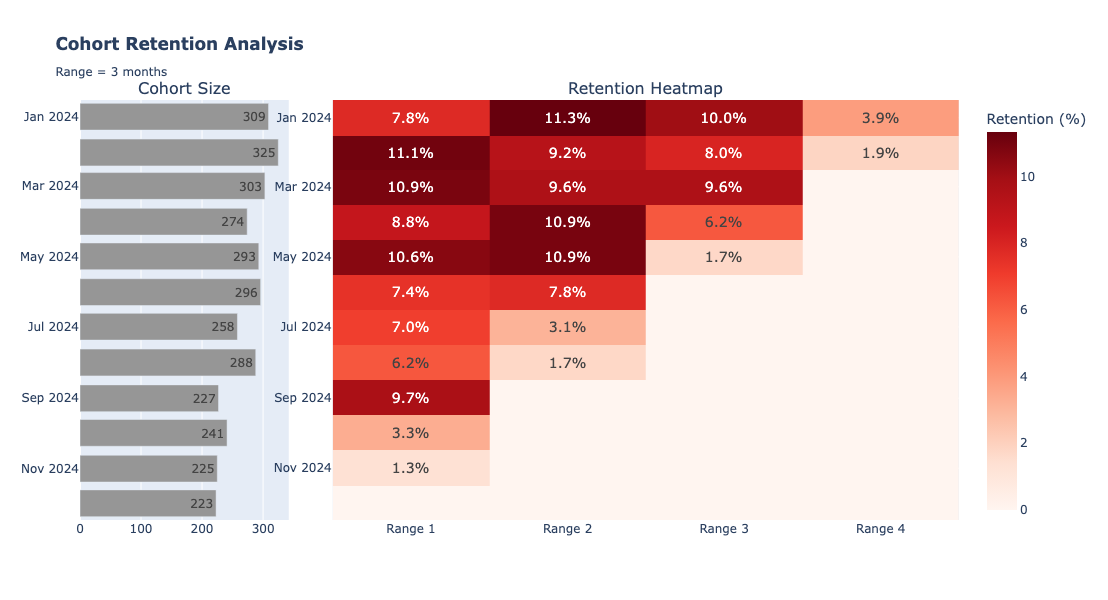

In [21]:
retention_rates = retention_df[['first_purchase_month', 'Range0', 'Range1_Rate', 'Range2_Rate', 'Range3_Rate', 'Range4_Rate']].copy()
retention_rates.columns = ['first_purchase_month', 'Range 0','Range 1', 'Range 2', 'Range 3', 'Range 4']

retention_matrix = retention_rates.set_index('first_purchase_month')
retention_matrix = retention_matrix.sort_index(ascending=False)

text_matrix = retention_matrix.copy()
text_matrix['Range 0'] = text_matrix['Range 0'].astype(int).astype(str)

# ⭐ 0%만 빈 문자열, 나머지는 표시
heatmap_values = retention_matrix[['Range 1','Range 2','Range 3','Range 4']]
custom_text = []
for row in heatmap_values.values:
    row_text = []
    for val in row:
        if val == 0:
            row_text.append('')  # 0%만 숨김
        else:
            row_text.append(f'{val:.1f}%')
    custom_text.append(row_text)

fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.25, 0.75],
    subplot_titles=("Cohort Size", "Retention Heatmap"),
    horizontal_spacing=0.05
)

fig.add_trace(
    go.Bar(
        x=retention_matrix['Range 0'],
        y=retention_matrix.index,
        orientation='h',
        text=retention_matrix['Range 0'],
        textposition='auto',
        marker_color='rgb(150,150,150)',
        showlegend=False
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Heatmap(
        z=heatmap_values.values,
        x=heatmap_values.columns,
        y=heatmap_values.index,
        colorscale='Reds',
        text=custom_text,  # ⭐ 0% 제외 텍스트
        texttemplate='%{text}',
        textfont={"size":14},
        colorbar=dict(title="Retention (%)")
    ),
    row=1,
    col=2
)

fig.update_yaxes(autorange="reversed")

fig.update_layout(
    title=dict(text='Cohort Retention Analysis<br><sub>Range = 3 months</sub>', font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'),
    height=600,
    width=1600
)

fig.show()

### 리텐션 추이 분석

히트맵에서 표본이 적은 후반 코호트는 값이 낮거나 공백으로 보일 수 있다.  
이를 보완하기 위해 **3% 미만 값은 신뢰도가 낮다고 판단하여 제외**하고,  
Range별 월별 리텐션 추이를 선 그래프로 시각화하여 패턴을 확인한다.

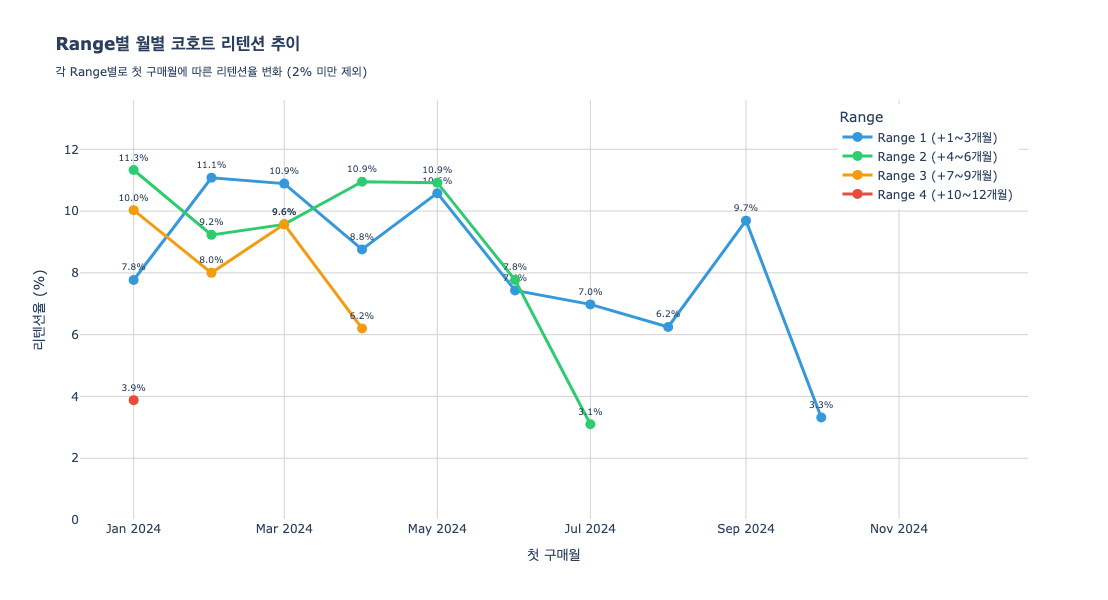

In [22]:
fig = go.Figure()

colors = {
    'Range1': '#3498db',
    'Range2': '#2ecc71', 
    'Range3': '#f39c12',
    'Range4': '#e74c3c'
}

# Range 1~4 각각에 대해 그래프 생성
for range_num in [1, 2, 3, 4]:
    range_name = f'Range{range_num}'
    range_col = f'Range{range_num}_Rate'
    
    # 2% 미만 제외 처리
    filtered_values = [v if v >= 3 else None for v in retention_df[range_col]]
    filtered_text = [f'{v:.1f}%' if v is not None else '' for v in filtered_values]
    
    fig.add_trace(go.Scatter(
        x=retention_df['first_purchase_month'],
        y=filtered_values,  # 2% 미만은 None
        mode='lines+markers+text',
        name=f'Range {range_num} (+{(range_num-1)*3+1}~{range_num*3}개월)',
        line=dict(color=colors[range_name], width=3),
        marker=dict(size=10),
        text=filtered_text,  # 2% 미만은 빈 문자열
        textposition='top center',
        textfont=dict(size=9),
        connectgaps=False,  # None 값 사이를 선으로 연결 안 함
        hovertemplate='%{x}<br>리텐션율: %{y:.1f}%<extra></extra>'
    ))

fig.update_layout(
    title=dict(
        text='Range별 월별 코호트 리텐션 추이<br><sub>각 Range별로 첫 구매월에 따른 리텐션율 변화 (3% 미만 제외)</sub>',
        font=dict(size=20, color='#2c3e50'),
        x=0.5, xanchor='center'
    ),
    xaxis_title='첫 구매월',
    yaxis_title='리텐션율 (%)',
    yaxis_range=[0, max(retention_df[['Range1_Rate', 'Range2_Rate', 'Range3_Rate', 'Range4_Rate']].max()) * 1.2],
    height=600,
    legend=dict(
        title='Range',
        orientation="v",
        yanchor="top",
        y=0.99,
        xanchor="right",
        x=0.99
    ),
    hovermode='x unified',
    plot_bgcolor='white',
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray'
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray'
    )
)

fig.show()

In [23]:
# Range 1~4 중 3% 이상인 값만으로 평균 계산
consistent_cohorts = []
for idx, row in retention_df.iterrows():
    cohort = row['first_purchase_month']
    
    # Range 1~4 모두 확인
    ranges = [
        row['Range1_Rate'],
        row['Range2_Rate'],
        row['Range3_Rate'],
        row['Range4_Rate']
    ]
    
    # 3% 이상인 값만 필터링
    valid_ranges = [r for r in ranges if r >= 3]
    
    if len(valid_ranges) >= 1:
        
        # 유효한 값들의 평균 (유효 개수로 나눔)
        avg_retention = sum(valid_ranges) / len(valid_ranges)
        
        consistent_cohorts.append({
            'cohort': cohort,
            'range1': row['Range1_Rate'],
            'range2': row['Range2_Rate'],
            'range3': row['Range3_Rate'],
            'range4': row['Range4_Rate'],
            'valid_count': len(valid_ranges),  # 유효한 Range 개수
            'avg': avg_retention,
            'pattern': '지속적 재구매'
        })

consistent_df = pd.DataFrame(consistent_cohorts).sort_values('avg', ascending=False)

if len(consistent_df) >= 2:
    # 전체 평균 계산
    overall_avg = consistent_df['avg'].mean()
    
    # Top 2만 출력
    top2_df = consistent_df.head(2)
    
    print(f"전체 평균 리텐션: {overall_avg:.2f}%\n")
    
    for _, row in top2_df.iterrows():
        print(f"{row['cohort']}")
        print(f"  R1: {row['range1']:.1f}% | R2: {row['range2']:.1f}% | R3: {row['range3']:.1f}% | R4: {row['range4']:.1f}%")
        print(f"  유효 Range: {row['valid_count']}개 | 평균: {row['avg']:.2f}% (전체 평균 대비 +{row['avg']-overall_avg:.2f}%p)\n")
else:
    print("Top 2를 선정할 수 없습니다.")

전체 평균 리텐션: 7.90%

2024-05
  R1: 10.6% | R2: 10.9% | R3: 1.7% | R4: 0.0%
  유효 Range: 2개 | 평균: 10.75% (전체 평균 대비 +2.85%p)

2024-03
  R1: 10.9% | R2: 9.6% | R3: 9.6% | R4: 0.0%
  유효 Range: 3개 | 평균: 10.01% (전체 평균 대비 +2.11%p)



### 집중 분석 대상 코호트 선정

코호트 리텐션 히트맵을 통해 2024년 신규 고객들의 재구매 패턴을 확인한 결과, 일부 코호트에서 여러 Range 구간에 걸쳐 높은 리텐션이 지속되는 패턴이 관찰되었다.

본 분석에서는 **3% 이상인 Range의 평균 리텐션**을 기준으로 상위 코호트를 선정하였으며, 다음 두 코호트가 가장 높은 리텐션을 보였다.

| 순위 | 코호트(첫 구매 기준) | R1 | R2 | R3 | R4 | 평균 리텐션 | 전체 평균 대비 |
|------|--------|-----|-----|-----|-----|------------|---------------|
| 1위 | 2024-05 | 10.6% | 10.9% | - | - | **10.75%** | **+36.1%** |
| 2위 | 2024-03 | 10.9% | 9.6% | 9.6% | - | **10.01%** | **+26.7%** |
| - | 전체 평균 | - | - | - | - | 7.90% | - |

두 코호트는 모두 전체 평균(7.90%) 대비 각각 **약 27, 약 36% 정도의 높은 리텐션**을 유지하면서도, **서로 다른 재구매 패턴**을 보인다는 점에서 주목할 만하다.

- **2024-05**: 초기 재구매 후 오히려 **중기(R2)에서 리텐션 상승** (10.6% → 10.9%)
- **2024-03**: Range 1~3까지 **일관되게 높은 리텐션 유지** (10.9% → 9.6% → 9.6%)

따라서 해당 코호트들을 집중 분석 대상으로 선정하고, 이들의 **구매 카테고리, 할인 패턴, 결제 방식** 등이 전체 고객과 어떤 차이를 보이는지 비교 분석하여 **높은 리텐션을 유도하는 요인을 파악**하고자 한다.

## 가설 설정

앞서 분석을 통해 리텐션이 높은 코호트는 단순히 평균 값이 높은 것이 아니라,  
여러 Range 구간에 걸쳐 **재구매 패턴이 지속적으로 나타나는 특징**을 보였다.

이러한 차이는 고객의 구매 행동, 가격 민감도, 상품 선호도 등의 요인에서 기인할 가능성이 있다.  
따라서 본 분석에서는 리텐션 차이를 설명할 수 있는 주요 요인을 다음과 같은 가설을 통해 검증하고자 한다.

### **가설1. 리텐션이 높은 코호트의 결제 방식 비율은 전체 코호트와 상이할 것이다.**  
→ 결제 방식은 고객의 구매 편의성 및 충성도와 관련이 있으며, 특정 결제 수단을 사용하는 고객이 더 높은 재구매율을 보일 가능성이 있다.

### **가설2. 리텐션이 높은 코호트의 할인 제품 구매 비율이 전체 코호트와 상이할 것이다.**  
→ 할인 및 프로모션은 재구매를 유도하는 주요 요인 중 하나로, 가격 혜택에 민감한 고객일수록 재구매 빈도가 높을 수 있다.

### **가설3. 리텐션이 높은 코호트가 많이 구매한 품목 카테고리 비율은 전체 코호트와 상이할 것이다.**  
→ 특정 상품 카테고리는 반복 구매 성향이 강할 수 있으며, 이러한 상품을 구매한 고객이 높은 리텐션을 보일 가능성이 있다.

이를 통해 각 요인이 실제로 리텐션에 어떤 영향을 미치는지 분석하고,  
향후 재구매율을 높일 수 있는 전략적 인사이트를 도출하고자 한다.